In [1]:
import gymnasium as gym
import numpy as np
import sys
from gymnasium.utils.env_checker import check_env

# add path

sys.path.append("..")

from experiments import TwoDimNavigationEnv
import tools.robots as robots
from tools.planners import MCGSPlanner


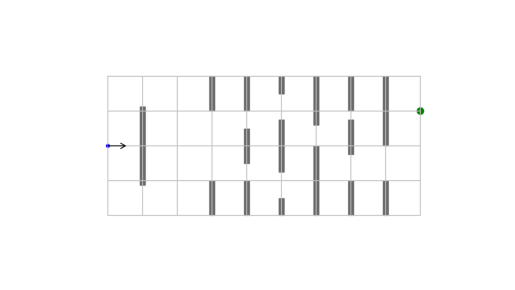

In [10]:
# check env using api function


env = TwoDimNavigationEnv(render_mode="human",
                          obstacle_mode="rect")

obs, info = env.reset()

# check_env(env, warn=True)
actions = [env.action_space.sample() for _ in range(10)]
print(np.array(actions))
for _ in range(10):   
    env.render()

    action = env.action_space.sample()
    obs, reward, finished, truncated, info = env.step(action)
    if finished or truncated:
        obs = env.reset()
env.close()

In [3]:
gym_agent = robots.GymAgent(id=0,
                     name="2D Navigation Agent",
                     env=env)

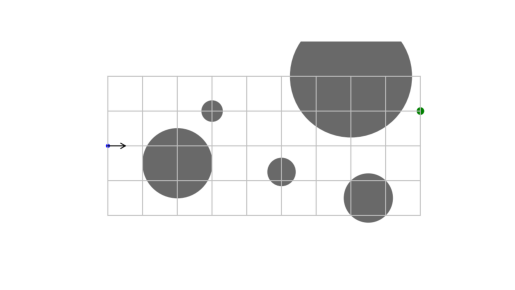

In [4]:
actions = []
observations = []
for _ in range(10):
    obs = gym_agent.state.observation
    observations.append(obs)
    action = gym_agent.sample_action()
    actions.append(action)
    # print(action)
    state = gym_agent.step(action)
    env, obs, reward, finished, truncated, info = state.to_components()
    if finished or truncated:
        obs = gym_agent.reset()
    gym_agent.state.env.render(render_mode="human")
# print("Actions taken by GymAgent:", np.array(actions))
# print("Observations received by GymAgent:", np.array(observations))

In [5]:
from tools.envs import GymRobotPlanEnv
from typing import Optional


class GymWrapperPlanEnv(GymRobotPlanEnv):
    def __init__(self, gym_robot:robots.GymRobot, planner: Optional[MCGSPlanner] = None, render_mode=None):
        self.gym_robot = gym_robot
        super().__init__(robot=self.gym_robot, planner=planner, render_mode=render_mode)

    def reward_function(self, state: robots.GymState):
        return state.reward

In [6]:
class TwoDimNavigationEnvRobot(robots.GymRobot):
    def __init__(self, id, name, state=None):
        self.env = TwoDimNavigationEnv(render_mode="human",
                                       obstacle_mode="circles")
        super().__init__(id=id, name=name, env=self.env)

    def encode_state(self, state):
        obs = state.observation
        # Encode the observation as a tensor
        return torch.tensor(obs, dtype=torch.float32)

    def controller(self, state, setpoint_state):
        obs = state.environment._get_obs()
        setpoint_obs = setpoint_state.environment._get_obs()
        # observations have the form [t, pos, vel]
        v_necessary = setpoint_obs[2] - obs[2]

In [7]:
planner = MCGSPlanner(robot=env.unwrapped.agent,
                      reward_function=env.unwrapped.reward_function,
                      max_iterations=500, 
                      expand_n_times=1,
                      kappa=1.6, # 1.6
                      alpha=0.3, # 0.3
                      k=8,
                      radius_threshold=0.0,#1.0, # 1.8,
                      abstraction_refinement_exponent=-0.1,
                      c_uct=0.4,
                      plan_in_space_time=False)

AttributeError: 'TwoDimNavigationEnv' object has no attribute 'agent'